In [1]:
import numpy as np
import pandas as pd
from utils.model_training import prepare_model_features
from sklearn.model_selection import train_test_split
import seaborn as sns
import matplotlib.pyplot as plt

# Deep Learning Introduction
Its been a long road to this point and I refer you to the introduction in the first notebook for more context, but tl;dr this notebook is an attempt to model the use of violence by the police during stop and frisk interactions.

All of the data comes from the NYPD itself via its published yearly data on NYC's open data website.  The bulk of EDA is in the second notebook.  This notebook is dedicated to building upon the (imho) inadequate results from earlier modeling to determine if a neural net can generalize better than its less complex model peers.

# (Where's the) EDA
For the sake of time and keeping things DRY, I will simply import the cleaned and prepared data, but a robust EDA writeup can be found in the [second notebook](./2.%20Exploratory%20Data%20Analysis.ipynb).

In [2]:
df = pd.read_csv(
    "./data/processed/stop-and-frisk.csv",
    parse_dates=["STOP_FRISK_DATE"],  
)

X, y = prepare_model_features(df)
assert not X.isnull().any().any(), "Null values remain in features"

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)


print("Train distribution:", y_train.value_counts(normalize=True), "\n")
print("Test distribution:", y_test.value_counts(normalize=True))

Train distribution: OFFICER_USED_FORCE
False    0.748507
True     0.251493
Name: proportion, dtype: float64 

Test distribution: OFFICER_USED_FORCE
False    0.748501
True     0.251499
Name: proportion, dtype: float64


In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, roc_curve
import numpy as np
import pandas as pd

class NYPDForcePredictor(nn.Module):
    def __init__(self, input_size, hidden_sizes=[128, 64, 32], dropout_rate=0.3):
        super(NYPDForcePredictor, self).__init__()
        
        # Build the network layers
        layers = []
        
        # Input layer
        layers.append(nn.Linear(input_size, hidden_sizes[0]))
        layers.append(nn.ReLU())
        layers.append(nn.BatchNorm1d(hidden_sizes[0]))
        layers.append(nn.Dropout(dropout_rate))
        
        # Hidden layers
        for i in range(len(hidden_sizes) - 1):
            layers.append(nn.Linear(hidden_sizes[i], hidden_sizes[i + 1]))
            layers.append(nn.ReLU())
            layers.append(nn.BatchNorm1d(hidden_sizes[i + 1]))
            layers.append(nn.Dropout(dropout_rate))
        
        # Output layer
        layers.append(nn.Linear(hidden_sizes[-1], 1))
        layers.append(nn.Sigmoid())
        
        self.network = nn.Sequential(*layers)
    
    def forward(self, x):
        return self.network(x)

class NYPDModelTrainer:
    def __init__(self, model, device='cpu'):
        self.model = model.to(device)
        self.device = device
        self.scaler = StandardScaler()
        
    def prepare_data(self, X, y, test_size=0.2, batch_size=512):
        """Prepare and scale the data for training"""
        # Split the data
        X_train, X_test, y_train, y_test = train_test_split(
            X, y, test_size=test_size, random_state=42, stratify=y
        )
        
        # Scale features
        X_train_scaled = self.scaler.fit_transform(X_train)
        X_test_scaled = self.scaler.transform(X_test)
        
        # Convert to tensors
        X_train_tensor = torch.FloatTensor(X_train_scaled)
        X_test_tensor = torch.FloatTensor(X_test_scaled)
        y_train_tensor = torch.FloatTensor(y_train.values).unsqueeze(1)
        y_test_tensor = torch.FloatTensor(y_test.values).unsqueeze(1)
        
        # Create data loaders
        train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
        test_dataset = TensorDataset(X_test_tensor, y_test_tensor)
        
        train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
        test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)
        
        return train_loader, test_loader, X_test_tensor, y_test_tensor
    
    def train(self, train_loader, test_loader, epochs=100, lr=0.001, weight_decay=1e-5, class_weighting=3.0, verbose=False):
        """Train the model with class weighting for imbalanced data"""
        # Calculate class weights (since force usage is 25% minority)
        pos_weight = torch.tensor([class_weighting]).to(self.device)  # 3.0 represents the 75/25 ratio underlying the class balances
        criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)
        
        # Use the model without final sigmoid for BCEWithLogitsLoss
        self.model.network = self.model.network[:-1]  # Remove sigmoid
        
        optimizer = optim.Adam(self.model.parameters(), lr=lr, weight_decay=weight_decay)
        scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, patience=10, factor=0.5)
        
        train_losses = []
        best_val_loss = float('inf')
        patience_counter = 0
        
        for epoch in range(epochs):
            # Training phase
            self.model.train()
            train_loss = 0.0
            
            for batch_X, batch_y in train_loader:
                batch_X, batch_y = batch_X.to(self.device), batch_y.to(self.device)
                
                optimizer.zero_grad()
                outputs = self.model(batch_X)
                loss = criterion(outputs, batch_y)
                loss.backward()
                optimizer.step()
                
                train_loss += loss.item()
            
            # Validation phase
            self.model.eval()
            val_loss = 0.0
            with torch.no_grad():
                for batch_X, batch_y in test_loader:
                    batch_X, batch_y = batch_X.to(self.device), batch_y.to(self.device)
                    outputs = self.model(batch_X)
                    loss = criterion(outputs, batch_y)
                    val_loss += loss.item()
            
            train_loss /= len(train_loader)
            val_loss /= len(test_loader)
            train_losses.append(train_loss)
            
            scheduler.step(val_loss)
            
            # Early stopping
            if val_loss < best_val_loss:
                best_val_loss = val_loss
                patience_counter = 0
                # Save best model
                torch.save(self.model.state_dict(), 'best_nn_nypd_model.pth')
            else:
                patience_counter += 1
                
            if patience_counter >= 15:
                print(f"Early stopping at epoch {epoch}")
                break
            
            if verbose and epoch % 10 == 0:
                print(f'Epoch {epoch}: Train Loss: {train_loss:.4f}, Val Loss: {val_loss:.4f}')
        
        # Load best model
        self.model.load_state_dict(torch.load('best_nn_nypd_model.pth'))
        
        # Add sigmoid back for predictions
        self.model.network = nn.Sequential(self.model.network, nn.Sigmoid())
        
        return train_losses
    
    def evaluate(self, X_test, y_test, verbose=False):
        """Evaluate the model and return metrics"""
        self.model.eval()
        
        with torch.no_grad():
            X_test = X_test.to(self.device)
            y_pred_proba = self.model(X_test).cpu().numpy()
            y_pred = (y_pred_proba > 0.5).astype(int)
        
        y_true = y_test.cpu().numpy()
        
        # Calculate metrics
        auc_score = roc_auc_score(y_true, y_pred_proba)
        
        if verbose:
            print("Classification Report:")
            print(classification_report(y_true, y_pred))
            print(f"\nAUC Score: {auc_score:.4f}")
            print("\nConfusion Matrix:")
            print(confusion_matrix(y_true, y_pred))
        
        return {
            'auc': auc_score,
            'predictions': y_pred,
            'probabilities': y_pred_proba
        }

# Usage Example:
def run_nypd_force_model(X, y, hidden_sizes=[128, 64, 32], dropout_rate=0.3, class_weighting = 3.0, lr=0.001, name="Unknown", verbose=False):
    """
    Main function to run the NYPD force prediction model
    X, y should come from your prepare_model_features() function
    """
    
    # Initialize model
    input_size = X.shape[1]
    model = NYPDForcePredictor(
        input_size=input_size,
        hidden_sizes=hidden_sizes,
        dropout_rate=dropout_rate,
    )
    
    # Initialize trainer
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    trainer = NYPDModelTrainer(model, device)
    
    print(f"Using model: {name}")
    print(f"Using device: {device}")
    print(f"Input features: {input_size}")
    print(f"Model parameters: {sum(p.numel() for p in model.parameters()):,}")
    
    # Prepare data
    train_loader, test_loader, X_test, y_test = trainer.prepare_data(X, y)
    
    # Train model
    print("\nStarting training...")
    train_losses = trainer.train(train_loader, test_loader, epochs=100, class_weighting=class_weighting, lr=lr)
    
    # Evaluate model
    verbose and print("\nEvaluating model...")
    results = trainer.evaluate(X_test, y_test)
    
    # Store y_true for comparison
    results['y_true'] = y_test.cpu().numpy().flatten()
    
    return trainer, results



Using model: Small Network
Using device: cuda
Input features: 26
Model parameters: 4,577

Starting training...
Epoch 0: Train Loss: 1.0327, Val Loss: 0.9941
Epoch 10: Train Loss: 0.9853, Val Loss: 0.9774
Epoch 20: Train Loss: 0.9854, Val Loss: 0.9760
Epoch 30: Train Loss: 0.9780, Val Loss: 0.9760
Early stopping at epoch 38

Evaluating model...
Added Small Network: AUC = 0.662
Using model: Medium Network
Using device: cuda
Input features: 26
Model parameters: 14,273

Starting training...
Epoch 0: Train Loss: 1.0261, Val Loss: 0.9815
Epoch 10: Train Loss: 0.9851, Val Loss: 0.9758
Epoch 20: Train Loss: 0.9806, Val Loss: 0.9753
Epoch 30: Train Loss: 0.9740, Val Loss: 0.9753
Early stopping at epoch 37

Evaluating model...
Added Medium Network: AUC = 0.663
Using model: Large Network
Using device: cuda
Input features: 26
Model parameters: 49,025

Starting training...
Epoch 0: Train Loss: 1.0214, Val Loss: 0.9780
Epoch 10: Train Loss: 0.9761, Val Loss: 0.9757
Epoch 20: Train Loss: 0.9737, Val 

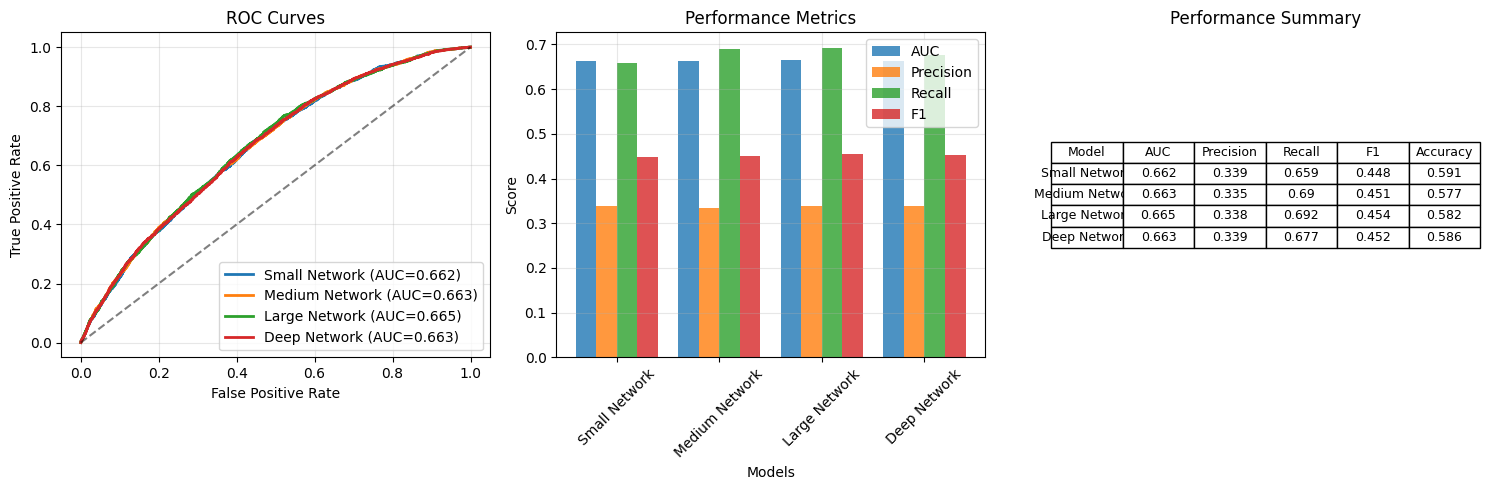

In [4]:
from sklearn.metrics import precision_score, recall_score, f1_score, accuracy_score

class ModelComparison:
    def __init__(self):
        self.results = {}
    
    def add_result(self, model_name, results_dict):
        """Add results from run_nypd_force_model to comparison"""
        self.results[model_name] = results_dict
        print(f"Added {model_name}: AUC = {results_dict['auc']:.3f}")
    
    def plot_comparison(self, figsize=(15, 5)):
        """Plot comparison of all tracked models"""
        if len(self.results) < 2:
            print("Need at least 2 models to compare")
            return
            
        fig, axes = plt.subplots(1, 3, figsize=figsize)
        
        # Collect metrics
        metrics_data = []
        
        # 1. ROC Curves
        for model_name, results in self.results.items():
            # Get stored probabilities and true labels
            y_pred_proba = results['probabilities']
            # We need to reconstruct y_true from the trainer that called this
            # For now, we'll use a workaround
            fpr, tpr, _ = roc_curve(results.get('y_true', []), y_pred_proba)
            auc = results['auc']
            axes[0].plot(fpr, tpr, label=f'{model_name} (AUC={auc:.3f})', linewidth=2)
            
            # Calculate other metrics from stored predictions
            y_pred = results['predictions']
            y_true = results.get('y_true', [])
            
            if len(y_true) > 0:  # If y_true is available
                precision = precision_score(y_true, y_pred)
                recall = recall_score(y_true, y_pred)
                f1 = f1_score(y_true, y_pred)
                accuracy = accuracy_score(y_true, y_pred)
            else:
                # Fallback values if y_true not stored
                precision = recall = f1 = accuracy = 0.0
            
            metrics_data.append({
                'Model': model_name,
                'AUC': auc,
                'Precision': precision,
                'Recall': recall,
                'F1': f1,
                'Accuracy': accuracy
            })
        
        axes[0].plot([0, 1], [0, 1], 'k--', alpha=0.5)
        axes[0].set_xlabel('False Positive Rate')
        axes[0].set_ylabel('True Positive Rate')
        axes[0].set_title('ROC Curves')
        axes[0].legend()
        axes[0].grid(True, alpha=0.3)
        
        # 2. Metrics Comparison Bar Chart
        df_metrics = pd.DataFrame(metrics_data)
        metrics_to_plot = ['AUC', 'Precision', 'Recall', 'F1']
        
        x = np.arange(len(df_metrics))
        width = 0.2
        
        for i, metric in enumerate(metrics_to_plot):
            axes[1].bar(x + i*width, df_metrics[metric], width, 
                       label=metric, alpha=0.8)
        
        axes[1].set_xlabel('Models')
        axes[1].set_ylabel('Score')
        axes[1].set_title('Performance Metrics')
        axes[1].set_xticks(x + width * 1.5)
        axes[1].set_xticklabels(df_metrics['Model'], rotation=45)
        axes[1].legend()
        axes[1].grid(True, alpha=0.3)
        
        # 3. Summary Table
        axes[2].axis('tight')
        axes[2].axis('off')
        
        display_df = df_metrics.round(3)
        table = axes[2].table(cellText=display_df.values,
                             colLabels=display_df.columns,
                             cellLoc='center',
                             loc='center')
        table.auto_set_font_size(False)
        table.set_fontsize(9)
        table.scale(1, 1.5)
        
        axes[2].set_title('Performance Summary')
        
        plt.tight_layout()
        return fig, df_metrics
    
    def print_summary(self):
        """Print a quick summary of all models"""
        print("\n" + "="*50)
        print("MODEL PERFORMANCE SUMMARY")
        print("="*50)
        
        for model_name, results in self.results.items():
            print(f"{model_name:20s} | AUC: {results['auc']:.3f}")
        
        best_model = max(self.results.items(), key=lambda x: x[1]['auc'])
        print("-"*50)
        print(f"Best Model: {best_model[0]} (AUC: {best_model[1]['auc']:.3f})")

def experiment_with_architectures(X, y):
    """
    Example of how to compare different model configurations
    """
    comparison = ModelComparison()
    
    # Test different architectures
    architectures = {
        'Small Network': [64, 32, 16],
        'Medium Network': [128, 64, 32], 
        'Large Network': [256, 128, 64],
        'Deep Network': [128, 128, 64, 32]
    }
    
    for name, arch in architectures.items():
        trainer, results = run_nypd_force_model(X, y, arch, name=name)
        comparison.add_result(name, results)
    
    # Plot comparison
    # fig, metrics_df = comparison.plot_comparison()
    comparison.plot_comparison()
    comparison.print_summary()
    
    return comparison

experiment_with_architectures(X, y)

# Model Training
I will train a variety of basic NN architectures varying across different hyperparameters for the hidden layer architecture as well as typical parameters (learning rate, dropout rate, etc.)

## Hyperparameter juicing is of little effect
Starting with a general foundation of hidden layer dimensions of [128,64,32], I tried doubling and halving the hidden dimensions to no general improvement of the model.  Similarly, increasing the dropout rate to .5/50% didn't improve the model, but did increase training time as expected.  

In [5]:
trainer, results = run_nypd_force_model(X, y)

Using model: Unknown
Using device: cuda
Input features: 26
Model parameters: 14,273

Starting training...
Epoch 0: Train Loss: 1.0269, Val Loss: 0.9859
Epoch 10: Train Loss: 0.9858, Val Loss: 0.9774
Epoch 20: Train Loss: 0.9764, Val Loss: 0.9759
Epoch 30: Train Loss: 0.9839, Val Loss: 0.9771
Epoch 40: Train Loss: 0.9770, Val Loss: 0.9759
Epoch 50: Train Loss: 0.9890, Val Loss: 0.9750
Epoch 60: Train Loss: 0.9664, Val Loss: 0.9763
Early stopping at epoch 70

Evaluating model...


In [6]:

trainer, results = run_nypd_force_model(X, y, [256, 128, 64])

Using model: Unknown
Using device: cuda
Input features: 26
Model parameters: 49,025

Starting training...
Epoch 0: Train Loss: 1.0166, Val Loss: 0.9776
Epoch 10: Train Loss: 0.9796, Val Loss: 0.9752
Epoch 20: Train Loss: 0.9803, Val Loss: 0.9743
Epoch 30: Train Loss: 0.9654, Val Loss: 0.9756
Early stopping at epoch 38

Evaluating model...


In [ ]:
trainer, results = run_nypd_force_model(X, y,[64, 32, 16])

Using model: Unknown
Using device: cuda
Input features: 26
Model parameters: 4,577

Starting training...
Epoch 0: Train Loss: 1.0410, Val Loss: 0.9948
Epoch 10: Train Loss: 0.9865, Val Loss: 0.9797
Epoch 20: Train Loss: 0.9820, Val Loss: 0.9787


In [ ]:
trainer, results = run_nypd_force_model(X, y, dropout_rate=.5)


Using device: cuda
Input features: 26
Model parameters: 14,273

Starting training...
Epoch 0: Train Loss: 1.0661, Val Loss: 0.9941
Epoch 10: Train Loss: 0.9897, Val Loss: 0.9808
Epoch 20: Train Loss: 0.9983, Val Loss: 0.9770
Epoch 30: Train Loss: 0.9802, Val Loss: 0.9756
Epoch 40: Train Loss: 0.9896, Val Loss: 0.9766
Early stopping at epoch 46

Evaluating model...
Classification Report:
              precision    recall  f1-score   support

         0.0       0.84      0.54      0.66      8241
         1.0       0.34      0.69      0.45      2769

    accuracy                           0.58     11010
   macro avg       0.59      0.62      0.55     11010
weighted avg       0.71      0.58      0.61     11010


AUC Score: 0.6625

Confusion Matrix:
[[4452 3789]
 [ 858 1911]]


In [ ]:
trainer, results = run_nypd_force_model(X, y, class_weighting=2.0)


Using device: cuda
Input features: 26
Model parameters: 14,273

Starting training...
Epoch 0: Train Loss: 0.8588, Val Loss: 0.8184
Epoch 10: Train Loss: 0.8026, Val Loss: 0.7916
Epoch 20: Train Loss: 0.7905, Val Loss: 0.7914
Epoch 30: Train Loss: 0.7898, Val Loss: 0.7909
Early stopping at epoch 38

Evaluating model...
Classification Report:
              precision    recall  f1-score   support

         0.0       0.79      0.83      0.81      8241
         1.0       0.40      0.34      0.37      2769

    accuracy                           0.70     11010
   macro avg       0.59      0.58      0.59     11010
weighted avg       0.69      0.70      0.70     11010


AUC Score: 0.6636

Confusion Matrix:
[[6816 1425]
 [1823  946]]


In [ ]:
trainer, results = run_nypd_force_model(X, y, class_weighting=1.0)


Using device: cuda
Input features: 26
Model parameters: 14,273

Starting training...
Epoch 0: Train Loss: 0.6961, Val Loss: 0.6359
Epoch 10: Train Loss: 0.5384, Val Loss: 0.5325
Epoch 20: Train Loss: 0.5355, Val Loss: 0.5323
Epoch 30: Train Loss: 0.5326, Val Loss: 0.5316
Early stopping at epoch 32

Evaluating model...
Classification Report:
              precision    recall  f1-score   support

         0.0       0.75      0.99      0.86      8241
         1.0       0.53      0.02      0.04      2769

    accuracy                           0.75     11010
   macro avg       0.64      0.51      0.45     11010
weighted avg       0.70      0.75      0.65     11010


AUC Score: 0.6619

Confusion Matrix:
[[8195   46]
 [2717   52]]


In [ ]:
# Learning rate modifications...
trainer, results = run_nypd_force_model(X, y, lr=0.003)


Using device: cuda
Input features: 26
Model parameters: 14,273

Starting training...
Epoch 0: Train Loss: 1.0082, Val Loss: 0.9800
Epoch 10: Train Loss: 0.9796, Val Loss: 0.9767
Epoch 20: Train Loss: 0.9735, Val Loss: 0.9752
Epoch 30: Train Loss: 0.9758, Val Loss: 0.9752
Epoch 40: Train Loss: 0.9808, Val Loss: 0.9764
Epoch 50: Train Loss: 0.9643, Val Loss: 0.9766
Early stopping at epoch 52

Evaluating model...
Classification Report:
              precision    recall  f1-score   support

         0.0       0.84      0.58      0.68      8241
         1.0       0.34      0.66      0.45      2769

    accuracy                           0.60     11010
   macro avg       0.59      0.62      0.57     11010
weighted avg       0.71      0.60      0.62     11010


AUC Score: 0.6656

Confusion Matrix:
[[4747 3494]
 [ 930 1839]]


In [ ]:
# 10x LR
trainer, results = run_nypd_force_model(X, y, lr=0.01)


Using device: cuda
Input features: 26
Model parameters: 14,273

Starting training...
Epoch 0: Train Loss: 1.0025, Val Loss: 0.9798
Epoch 10: Train Loss: 0.9798, Val Loss: 0.9800
Epoch 20: Train Loss: 0.9815, Val Loss: 0.9754
Epoch 30: Train Loss: 0.9779, Val Loss: 0.9749
Epoch 40: Train Loss: 0.9705, Val Loss: 0.9762
Early stopping at epoch 43

Evaluating model...
Classification Report:
              precision    recall  f1-score   support

         0.0       0.84      0.54      0.66      8241
         1.0       0.34      0.69      0.45      2769

    accuracy                           0.58     11010
   macro avg       0.59      0.62      0.56     11010
weighted avg       0.71      0.58      0.61     11010


AUC Score: 0.6631

Confusion Matrix:
[[4458 3783]
 [ 854 1915]]


In [ ]:
# Let's try some combos...
trainer, results = run_nypd_force_model(X, y, dropout_rate=.5, class_weighting=1.0)


Using device: cuda
Input features: 26
Model parameters: 14,273

Starting training...
Epoch 0: Train Loss: 0.7156, Val Loss: 0.6204
Epoch 10: Train Loss: 0.5445, Val Loss: 0.5345
Epoch 20: Train Loss: 0.5381, Val Loss: 0.5329
Epoch 30: Train Loss: 0.5434, Val Loss: 0.5327
Epoch 40: Train Loss: 0.5344, Val Loss: 0.5331
Epoch 50: Train Loss: 0.5351, Val Loss: 0.5320
Epoch 60: Train Loss: 0.5353, Val Loss: 0.5319
Early stopping at epoch 67

Evaluating model...
Classification Report:
              precision    recall  f1-score   support

         0.0       0.75      0.99      0.86      8241
         1.0       0.48      0.02      0.03      2769

    accuracy                           0.75     11010
   macro avg       0.62      0.51      0.44     11010
weighted avg       0.68      0.75      0.65     11010


AUC Score: 0.6621

Confusion Matrix:
[[8194   47]
 [2725   44]]


In [ ]:
trainer, results = run_nypd_force_model(X, y,hidden_sizes=[256,128,64],  dropout_rate=.5, class_weighting=2.5)


Using device: cuda
Input features: 26
Model parameters: 49,025

Starting training...
Epoch 0: Train Loss: 0.9554, Val Loss: 0.9010
Epoch 10: Train Loss: 0.8972, Val Loss: 0.8925
Epoch 20: Train Loss: 0.8942, Val Loss: 0.8904
Epoch 30: Train Loss: 0.8911, Val Loss: 0.8907
Epoch 40: Train Loss: 0.8951, Val Loss: 0.8898
Epoch 50: Train Loss: 0.8888, Val Loss: 0.8899
Epoch 60: Train Loss: 0.8944, Val Loss: 0.8895
Epoch 70: Train Loss: 0.8903, Val Loss: 0.8892
Epoch 80: Train Loss: 0.8882, Val Loss: 0.8893
Early stopping at epoch 83

Evaluating model...
Classification Report:
              precision    recall  f1-score   support

         0.0       0.81      0.68      0.74      8241
         1.0       0.36      0.52      0.42      2769

    accuracy                           0.64     11010
   macro avg       0.58      0.60      0.58     11010
weighted avg       0.70      0.64      0.66     11010


AUC Score: 0.6625

Confusion Matrix:
[[5642 2599]
 [1327 1442]]


In [ ]:
trainer, results = run_nypd_force_model(X, y,hidden_sizes=[256,128,64],  dropout_rate=.5, class_weighting=2.5, lr=0.01)

Using device: cuda
Input features: 26
Model parameters: 49,025

Starting training...
Epoch 0: Train Loss: 0.9213, Val Loss: 0.8943
Epoch 10: Train Loss: 0.8968, Val Loss: 0.8933
Epoch 20: Train Loss: 0.8902, Val Loss: 0.8890
Epoch 30: Train Loss: 0.8949, Val Loss: 0.8889
Epoch 40: Train Loss: 0.8884, Val Loss: 0.8908
Epoch 50: Train Loss: 0.8846, Val Loss: 0.8874
Epoch 60: Train Loss: 0.8885, Val Loss: 0.8880
Early stopping at epoch 65

Evaluating model...
Classification Report:
              precision    recall  f1-score   support

         0.0       0.81      0.68      0.74      8241
         1.0       0.36      0.54      0.43      2769

    accuracy                           0.64     11010
   macro avg       0.59      0.61      0.58     11010
weighted avg       0.70      0.64      0.66     11010


AUC Score: 0.6645

Confusion Matrix:
[[5579 2662]
 [1278 1491]]


In [ ]:
trainer, results = run_nypd_force_model(X, y,hidden_sizes=[256,128,64],  dropout_rate=.5, class_weighting=2.5, lr=0.05)

Using device: cuda
Input features: 26
Model parameters: 49,025

Starting training...
Epoch 0: Train Loss: 0.9247, Val Loss: 0.9041
Epoch 10: Train Loss: 0.9115, Val Loss: 0.8928
Epoch 20: Train Loss: 0.9114, Val Loss: 0.9051
Epoch 30: Train Loss: 0.9058, Val Loss: 0.8989
Epoch 40: Train Loss: 0.9096, Val Loss: 0.8928
Epoch 50: Train Loss: 0.9033, Val Loss: 0.8958
Epoch 60: Train Loss: 0.9021, Val Loss: 0.8906
Epoch 70: Train Loss: 0.8949, Val Loss: 0.8915
Early stopping at epoch 71

Evaluating model...
Classification Report:
              precision    recall  f1-score   support

         0.0       0.81      0.69      0.75      8241
         1.0       0.36      0.51      0.42      2769

    accuracy                           0.65     11010
   macro avg       0.58      0.60      0.58     11010
weighted avg       0.69      0.65      0.66     11010


AUC Score: 0.6624

Confusion Matrix:
[[5726 2515]
 [1364 1405]]


### Juicing moderately works
Tl;dr, increasing the hidden dimensions, increasing the dropout rate to 50%, decreasing the class imbalance weighting from 3.0 -> 2.5, and a 50x increase in learning rate from 0.001 -> 0.05 improved overall accuracy ~58% -> 64%. 

All of these results aren't markedly better than the linear supervised models that I initially trained, with top accuracy reaching ~70%, though both models only achieve this accuracy by overfitting the majority class. 

## Standing on the shoulders of giants (i.e. myself)
Though I didn't get fully improved results via unsupervised learning, I did pull out a new feature which did help model performance.  I will pull that in here. TBD.

In [ ]:
# Very hacky and temporary....
pca_X = pd.read_csv(
    "./data/processed/pca_X.csv",
).iloc[:, 1:]

pca_y = pd.read_csv(
    "./data/processed/pca_y.csv",
)["OFFICER_USED_FORCE"]


In [ ]:
trainer, results = run_nypd_force_model(pca_X, pca_y, dropout_rate=.5, class_weighting=2.5, lr=0.05)

Using device: cuda
Input features: 27
Model parameters: 14,401

Starting training...
Epoch 0: Train Loss: 0.9379, Val Loss: 0.9096
Epoch 10: Train Loss: 0.9050, Val Loss: 0.9000
Epoch 20: Train Loss: 0.8996, Val Loss: 0.8918
Epoch 30: Train Loss: 0.9044, Val Loss: 0.8955
Epoch 40: Train Loss: 0.8999, Val Loss: 0.8904
Epoch 50: Train Loss: 0.9023, Val Loss: 0.8909
Epoch 60: Train Loss: 0.8932, Val Loss: 0.8897
Epoch 70: Train Loss: 0.8908, Val Loss: 0.8903
Epoch 80: Train Loss: 0.8965, Val Loss: 0.8887
Epoch 90: Train Loss: 0.8889, Val Loss: 0.8902

Evaluating model...
Classification Report:
              precision    recall  f1-score   support

         0.0       0.81      0.69      0.75      8241
         1.0       0.36      0.52      0.42      2769

    accuracy                           0.65     11010
   macro avg       0.58      0.60      0.58     11010
weighted avg       0.70      0.65      0.66     11010


AUC Score: 0.6634

Confusion Matrix:
[[5691 2550]
 [1336 1433]]


In [ ]:
trainer, results = run_nypd_force_model(pca_X, pca_y,hidden_sizes=[256,128,64],  dropout_rate=.5, class_weighting=2.5, lr=0.05)

Using device: cuda
Input features: 28
Model parameters: 49,537

Starting training...
Epoch 0: Train Loss: 0.9305, Val Loss: 0.8943
Epoch 10: Train Loss: 0.9067, Val Loss: 0.9058
Epoch 20: Train Loss: 0.9023, Val Loss: 0.8941
Epoch 30: Train Loss: 0.9015, Val Loss: 0.8918
Epoch 40: Train Loss: 0.9016, Val Loss: 0.8951
Epoch 50: Train Loss: 0.8997, Val Loss: 0.8900
Epoch 60: Train Loss: 0.8941, Val Loss: 0.8912
Epoch 70: Train Loss: 0.8934, Val Loss: 0.8899
Epoch 80: Train Loss: 0.8884, Val Loss: 0.8901
Early stopping at epoch 82

Evaluating model...
Classification Report:
              precision    recall  f1-score   support

         0.0       0.82      0.66      0.73      8241
         1.0       0.35      0.56      0.43      2769

    accuracy                           0.63     11010
   macro avg       0.59      0.61      0.58     11010
weighted avg       0.70      0.63      0.65     11010


AUC Score: 0.6626

Confusion Matrix:
[[5406 2835]
 [1217 1552]]


In [ ]:
results

{'auc': 0.6634039721325724,
 'predictions': array([[1],
        [0],
        [0],
        ...,
        [0],
        [0],
        [0]]),
 'probabilities': array([[0.54100966],
        [0.4950889 ],
        [0.45160845],
        ...,
        [0.23962024],
        [0.3998616 ],
        [0.4902634 ]], dtype=float32)}

### Or Maybe Not
No significant improvement in model performance with the unsupervised learning augmentation :( 

# Results + Conclusions
"Modelling is hard" - Zoolander 

Less flippantly, I really expected neural net architectures to generalize much better to be honest.  The overall model performance mirrored supervised models at best, but with far more computation.  

The only significant benefit is that given neural nets are better equipped to handle higher dimensional data, I was able to confirm that the earlier models were not bottlenecked by the inclusion of too many features.

Regardless, I will continue this research until I get to a place where I can state some positive results.  
## Next steps 
- feature engineering given that seems to be the major hurdle after the failure of these various models.
- experimenting with other deep neural net architectures
- integrating SHAP analysis for more feature auditing